In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.models.apogee import APOGEEData, APOGEETrainingSet, APOGEESpectra
from ugdatalab.models.apogee.constants import (
    LABEL_NAMES,
    LABEL_LATEX,
    APOGEE_BAD_PIXMASK_BITS,
)
from ugdatalab.models.apogee.spectra import (
    _get_apstar_spectra,
    _apply_bitmask,
    _normalize_spectrum,
    _fetch_apstar_batch,  # TODO(audit-H6): replace with public wrapper
)

import plotters

# APOGEE / Cannon Lab — Training Set

We use the Apache Point Observatory Galactic Evolution Experiment (APOGEE) survey, part of SDSS-IV/V. APOGEE observes in the near-infrared $H$ band (15100–17000 Å) for two reasons: (1) interstellar extinction is roughly five times lower in $H$ than in optical bands, opening a clear view through the dusty Galactic disk and bulge; and (2) the $H$ band is rich in absorption features from $\sim 15$ elements (Fe, Mg, Si, Al, Ca, Ti, Mn, Ni, C, N, O, K, Na, S, V, …), making it ideal for chemical-abundance work on cool stars.

Each spectrum is recorded at $R \approx 22{,}500$ across three Hawaii-2RG (H2RG) infrared detectors — referred to throughout as the *blue*, *green*, and *red* chips — with small physical gaps between them. After resampling to a common log-linear wavelength grid the coadded spectrum has 8575 pixels. Throughout this notebook we treat the spectrum as a single 8575-pixel vector but always remember that there are three independent chips behind it: continuum normalization, bitmask handling, and the Cannon's intrinsic-scatter terms all need to respect the chip structure.

## Problem 1 — Training Set Selection

### Query APOGEE DR17 catalog

We assemble a training set from four APOGEE DR17 fields, deliberately chosen to span a wide range of metallicities and evolutionary states:

- **M15** — a metal-poor halo globular cluster ($[\mathrm{Fe/H}] \approx -2.3$ at the cluster mean; the post-cut survivors sit near our metallicity floor and anchor the metal-poor end of the training distribution).
- **NGC 6791** — one of the most metal-rich open clusters known ($[\mathrm{Fe/H}] \approx +0.4$); anchors the metal-rich end.
- **K2_C4_168-21** — a *K2* mission field of disk giants spanning intermediate metallicities; provides bulk statistics and breaks the cluster-only degeneracy where labels are coupled to a single cluster age.
- **060+00** — an inner-disk / bulge field at galactic coordinates $(\ell, b) = (60°, 0°)$ with broad chemical and evolutionary spread, including α-enhanced thick-disk and bulge giants.

Together these four fields bracket the metallicity ladder from $[\mathrm{Fe/H}] \approx -1$ (after our cut, see below) to $\approx +0.4$, and span the entire RGB plus the red clump in the Kiel diagram. This diversity is essential for the Cannon: a polynomial spectral model can only interpolate within the convex hull of its training labels, so the training set must cover the label space the model will later be asked to fit.

In [2]:
query = """
SELECT *
FROM apogeeStar AS s
JOIN aspcapStar AS a
    ON s.apstar_id = a.apstar_id
WHERE s.field IN ('M15', 'N6791', 'K2_C4_168-21', '060+00')
"""

source = APOGEEData(query)

### Apply quality cuts

We select a training set by requiring all of the following. Each cut has a specific role; they are not interchangeable and not chosen for convenience.

- **All five ASPCAP labels finite and not the NULL sentinel** ($-9999$). The Cannon needs *every* label to be valid for *every* training star — the polynomial design matrix is built from the joint label vector, and a missing label would force us to drop the row entirely (so we drop it now and report an honest training-set size).
- **SNR $> 50$.** Per-pixel uncertainties scale as $1/\mathrm{SNR}$. Below SNR $\sim 50$ the photon noise dominates the model-inadequacy budget, so the Cannon's intrinsic-scatter term $s_\lambda^2$ would be driven by data quality rather than by genuine label-dependent residuals — the term loses its physical meaning. The cut keeps photon noise comparable to or below the irreducible model error.
- **$\log g \leq 4$.** Removes the main sequence and most subgiants; selects red giants and red-clump stars. The physical justification is in the surface-gravity calculation below: $\log g = 4$ is roughly where stars transition out of hydrogen core burning.
- **$T_{\rm eff} \leq 5700\,\mathrm{K}$.** Complementary cut against the warm dwarf/turnoff regime. Above $\sim 5700$ K the $H$ band becomes increasingly dominated by the (essentially label-insensitive) Brackett-series wings, and the metal-line content drops sharply — the Cannon's polynomial response collapses, abundances become poorly constrained, and the training residuals balloon. Restricting to cool giants keeps the model in the regime where it has real diagnostic power.
- **$[\mathrm{Fe/H}] \geq -1$.** A 2nd-order polynomial in five labels can extrapolate dangerously into the metal-poor tail (very few training stars there means the design matrix becomes locally rank-deficient and a single anomalous star can drive the local coefficients). Cutting at $-1$ keeps us inside the well-populated body of the metallicity distribution.

After these cuts the training set will contain $\sim 1900$ stars (the precise count is reported below after the spectra are downloaded).

In [3]:
training = APOGEETrainingSet(source)

### Surface gravity calculation

Surface gravity is $g = GM/R^2$. For a solar-mass star ($M = M_\odot$), the ratio to solar surface gravity gives:

$$\log g = \log g_\odot + \log\left(\frac{M}{M_\odot}\right) - 2\log\left(\frac{R}{R_\odot}\right) = 4.44 - 2\log_{10}\left(\frac{R}{R_\odot}\right) \quad\text{(CGS)}$$

where $\log g_\odot = 4.44$ in CGS units. This formula assumes $M = M_\odot$ throughout; in practice mass varies along the giant branch, but only logarithmically (a factor-of-2 mass difference shifts $\log g$ by just 0.3 dex), so the radius term dominates.

**Why $\log g \leq 4$ selects giants.** On the main sequence a solar-mass star has $R \approx 1\,R_\odot$ and $\log g \approx 4.44$. After core hydrogen exhaustion the star expands to $R \sim 10$–$100\,R_\odot$ while its mass barely changes, driving $\log g$ down to $\sim 0$–$3$. The cut at $\log g = 4$ therefore falls between the main-sequence locus ($\log g \sim 4.0$–$4.6$ for FGK dwarfs) and the subgiant branch, cleanly selecting evolved stars. The table below gives representative values at three evolutionary stages:

In [4]:
# Surface gravity at three evolutionary stages for a solar-mass star
logg_sun = 4.44  # log g_sun in CGS

stages = pd.DataFrame({
    "Stage": ["Main sequence", "Pre-He flash (tip RGB)", "Core He burning (red clump)"],
    "R / R_sun": [1, 100, 15],
})
stages["log g"] = logg_sun - 2 * np.log10(stages["R / R_sun"])
stages

,Stage,R / R_sun,log g
0,Main sequence,1,4.440000
1,Pre-He flash (tip RGB),100,0.440000
2,Core He burning (red clump),15,2.087817


### Label corner plot

The corner plot below shows the joint distribution of the five ASPCAP labels across the full post-cut training set. Each diagonal panel is a 1-D marginal histogram; the off-diagonal panels are 2-D scatter/contour views of every label pair. A few features to look for:

- The **$T_{\rm eff}$–$\log g$** panel traces out the upper red giant branch and the red clump (the dense knot near $T_{\rm eff} \approx 4800$ K, $\log g \approx 2.5$). This is the Kiel diagram of the training set; we will revisit it in NB 03 with isochrone overlays.
- The **$[\mathrm{Mg/Fe}]$–$[\mathrm{Si/Fe}]$** panel shows a tight positive correlation, as expected for two α-elements that track each other in nucleosynthesis.
- The **$[\mathrm{Fe/H}]$** marginal is bimodal: the metal-rich peak comes from NGC 6791 and the disk/bulge giants, the metal-poor tail from M15 survivors and metal-poor halo stars in the bulge field.
- The cluster of cool, metal-poor, low-$\log g$ stars at the upper-left of the $T_{\rm eff}$–$\log g$ panel is dominated by M15 RGB stars; the metal-rich, slightly warmer clump on the right comes from NGC 6791. The surrounding diffuse cloud is field giants from the K2 and bulge fields.

The label distribution is the *prior support* of the Cannon model — the polynomial can interpolate confidently inside this cloud and only extrapolate at its own peril outside it.

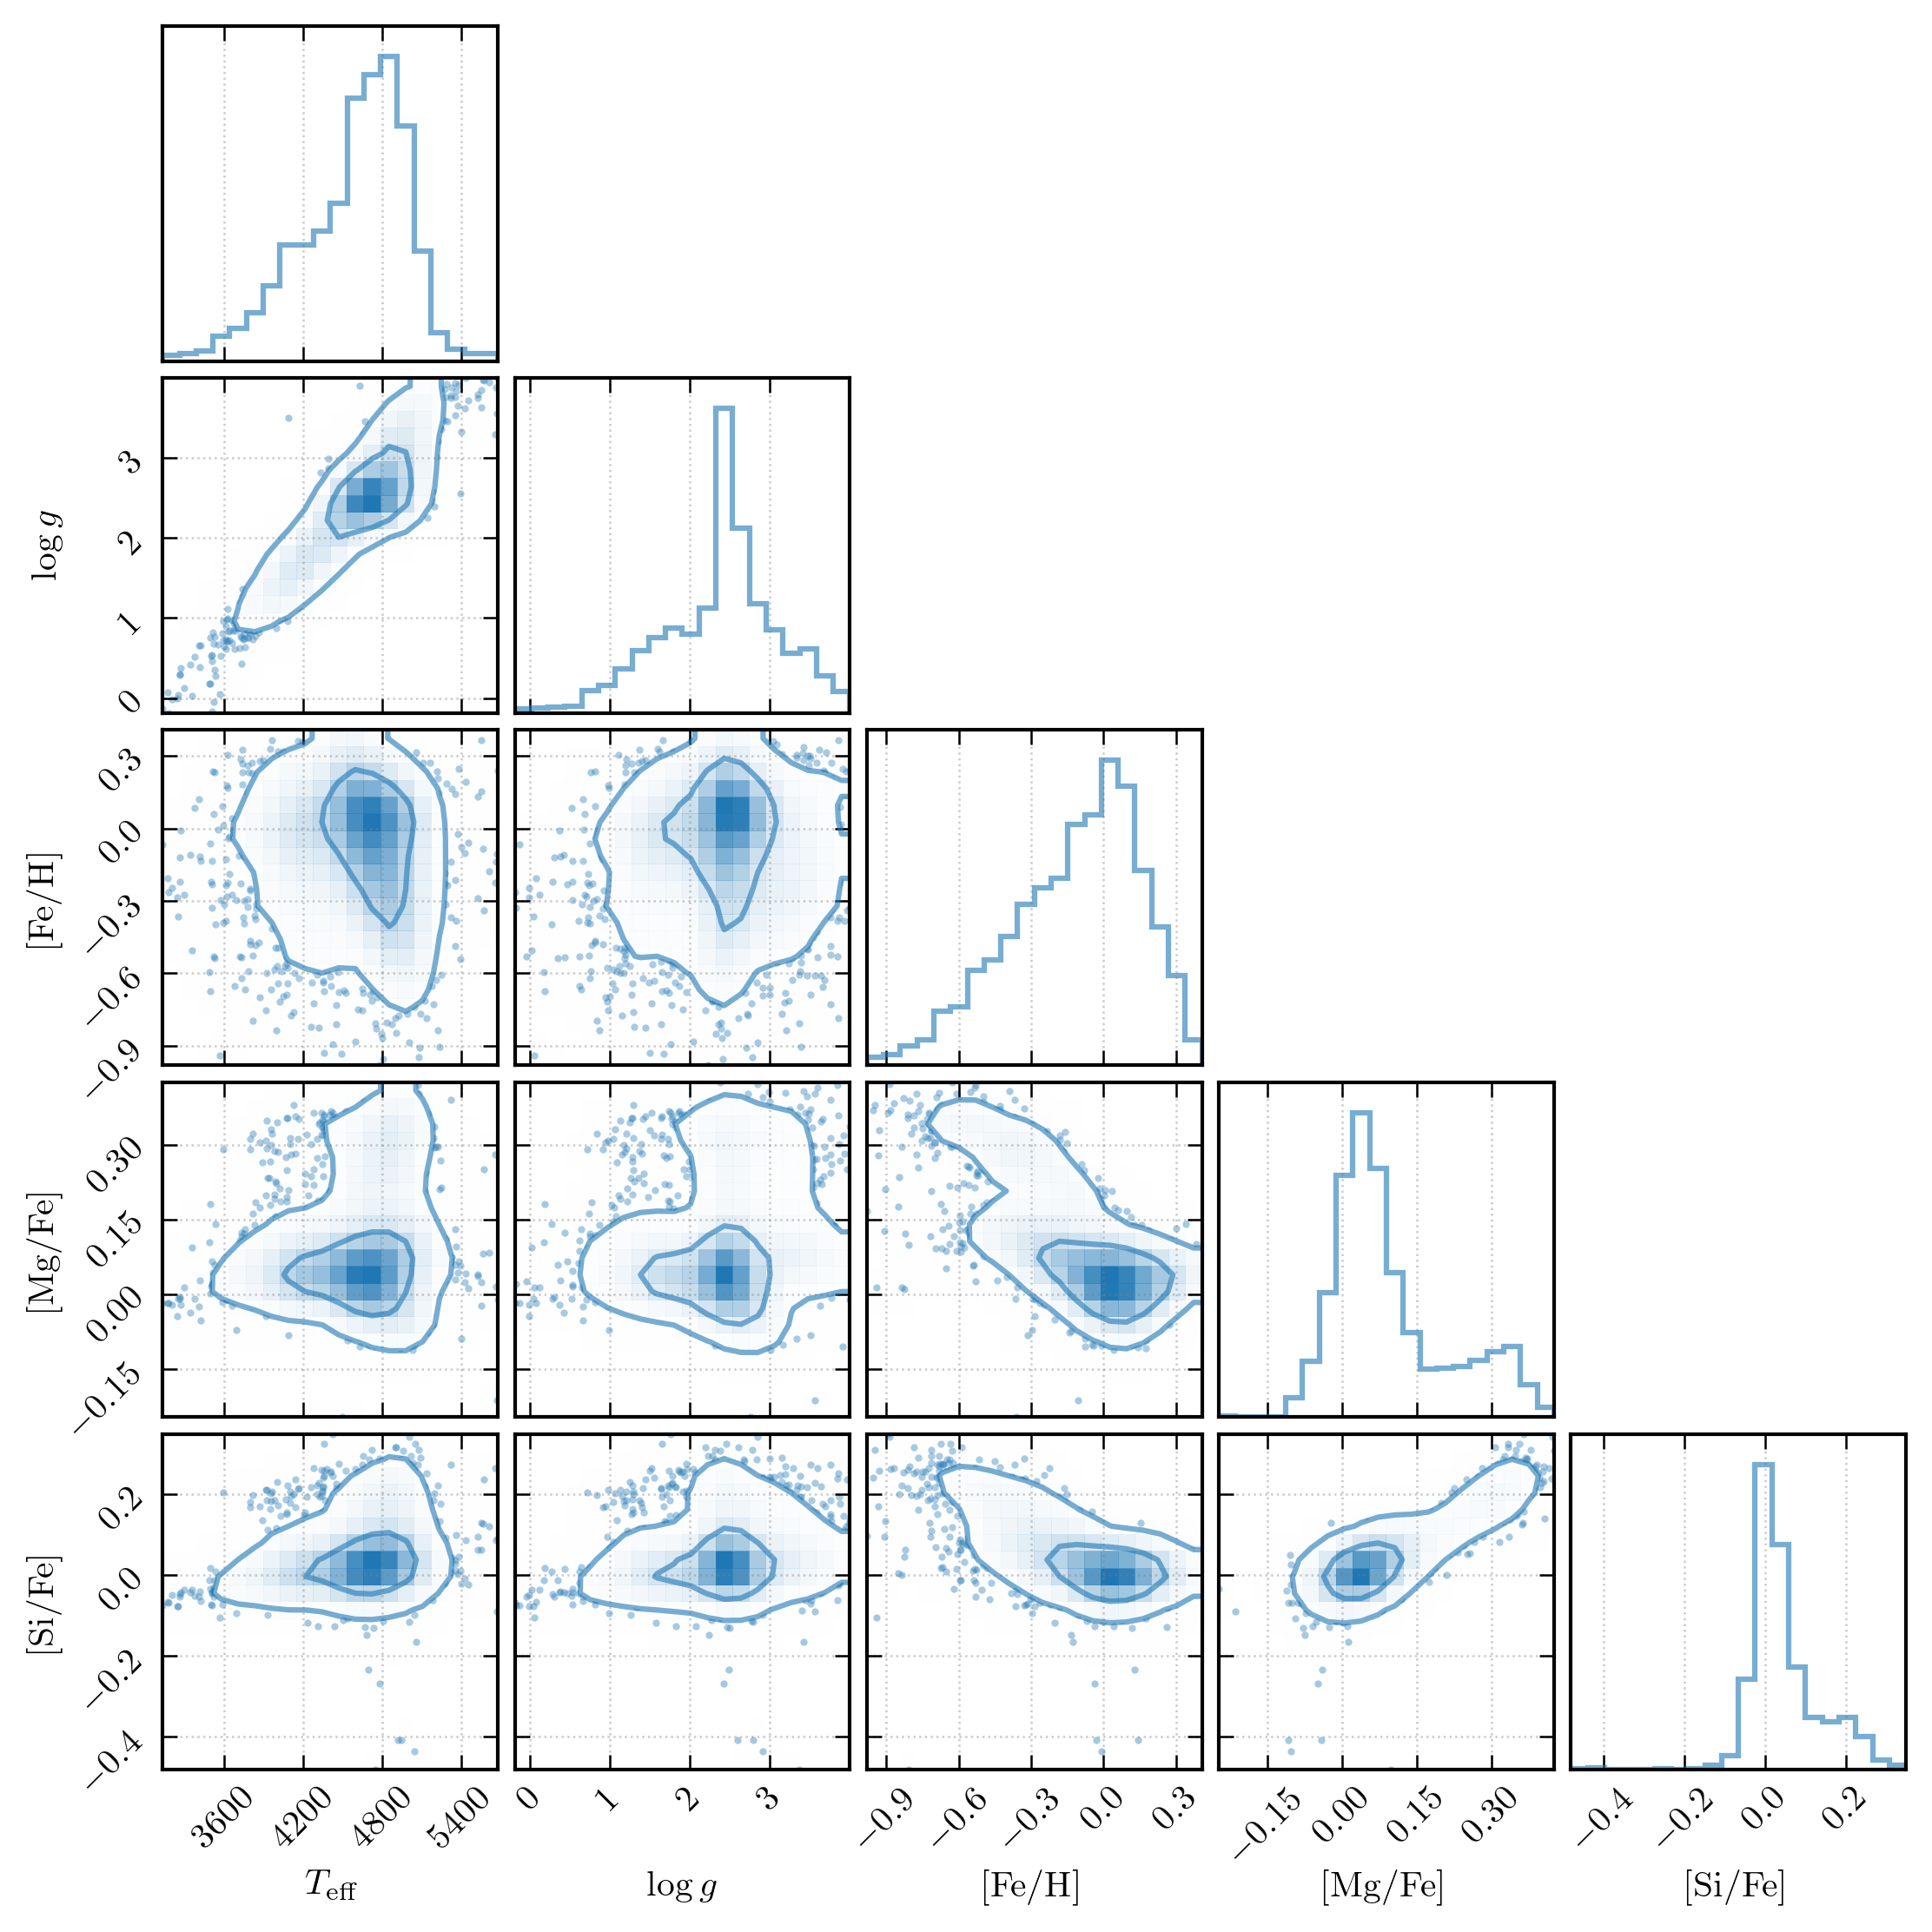

In [5]:
label_cols = ["teff", "logg", "fe_h", "mg_fe", "si_fe"]
labels = np.column_stack([training.data[col] for col in label_cols])

fig = plotters.plot_label_corner(labels, LABEL_LATEX)
plt.show()

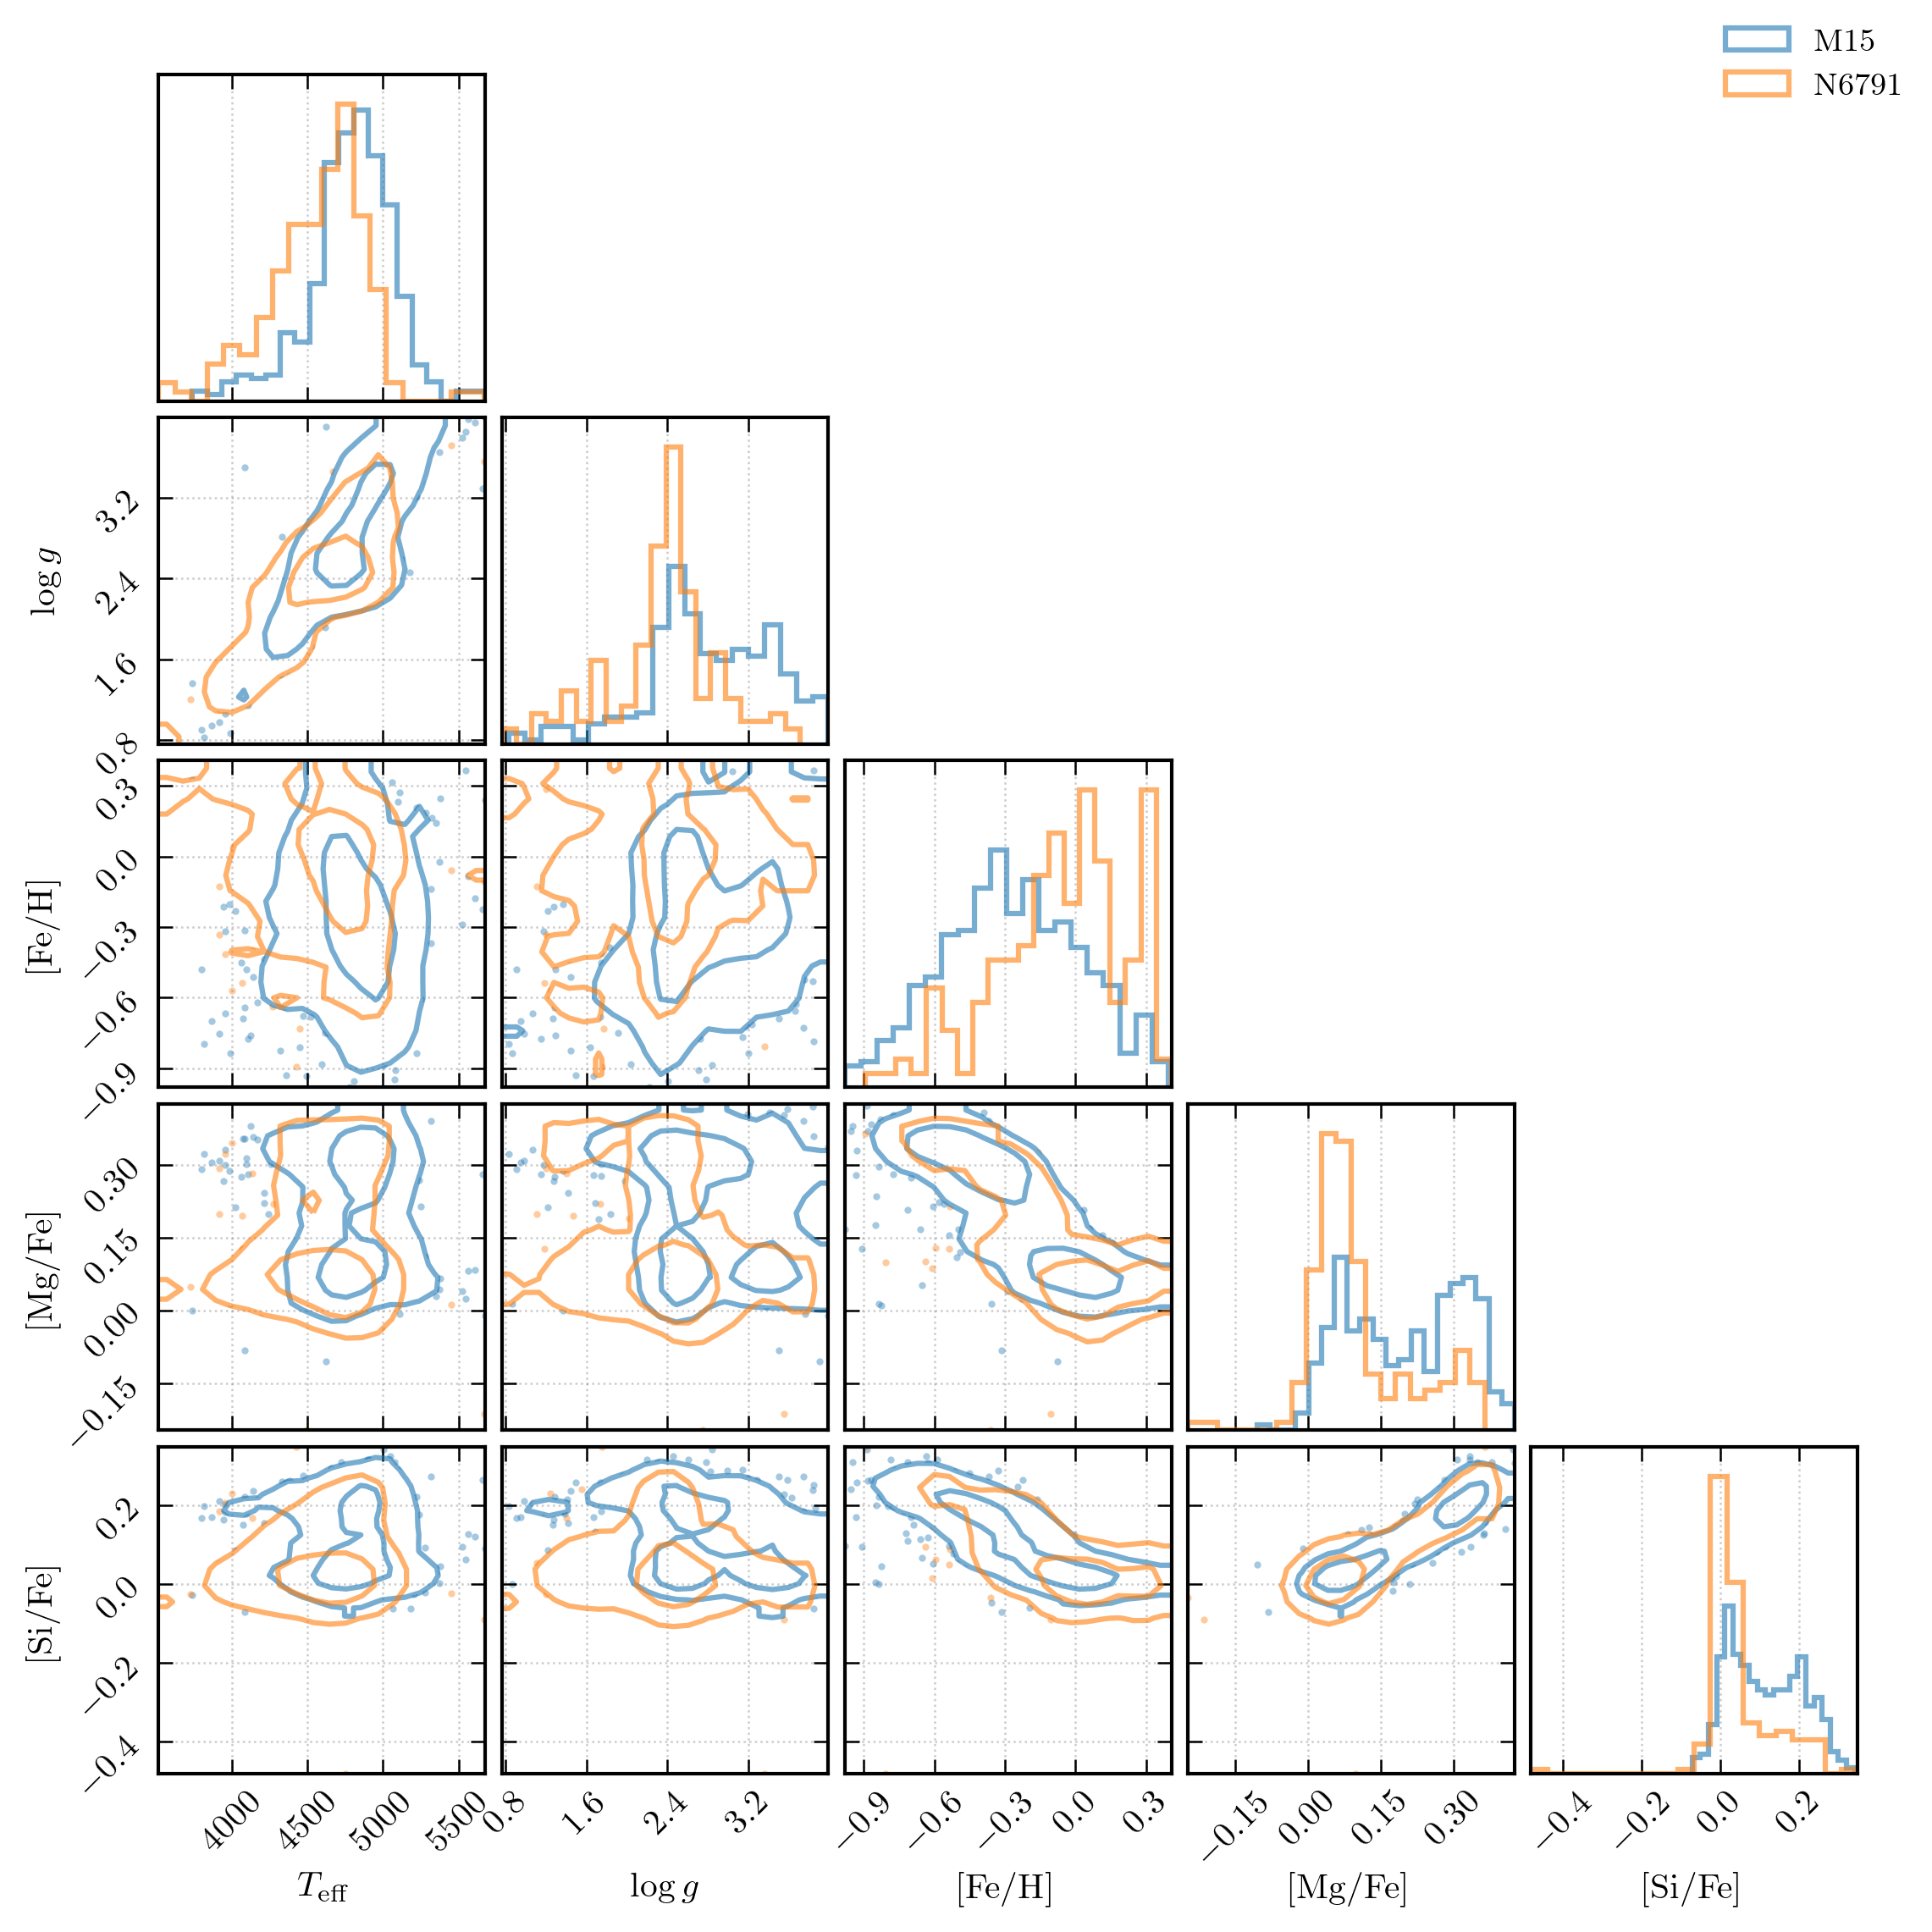

In [6]:
fields = np.array(training.data["field"], dtype=str)
mask = np.isin(fields, ["M15", "N6791"])
fig = plotters.plot_label_corner_by_field(labels[mask], LABEL_LATEX, fields[mask])
plt.show()

Restricting the same corner plot to just the M15 and NGC 6791 sub-samples makes the cluster identity of the two metallicity peaks unambiguous. M15 occupies the metal-poor, α-enhanced corner; NGC 6791 occupies the metal-rich corner with α-element ratios near solar. Within each cluster the labels are tight (single age, single chemical history), confirming that the ASPCAP labels are internally consistent on a per-cluster basis.

## Problem 2 — Download Spectra

### Raw spectrum example

We download one spectrum to examine before normalization. APOGEE (Majewski et al. 2017) spectra are in units of $10^{-17}\,\mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}$ (spectral flux density: the energy received per unit time, per unit collecting area, per unit wavelength interval) on a barycentric wavelength grid.

**Barycentric frame.** Each individual visit spectrum is observed at a slightly different wavelength scale because the Earth's orbital velocity ($\sim 30\,\mathrm{km\,s^{-1}}$) projects differently onto the line of sight to the target depending on when in the year the observation was taken. The Doppler shift is $\Delta\lambda / \lambda = v_{\rm bary}/c$, where $v_{\rm bary}$ is the component of the Earth's velocity along the line of sight to the star. For a typical visit, $|v_{\rm bary}| \sim 10$–$30\,\mathrm{km\,s^{-1}}$, giving $\Delta\lambda / \lambda \sim 3 \times 10^{-5}$–$10^{-4}$, or $\sim 0.5$–$1.7$ Å at $\lambda = 16000$ Å. This shift is different for each visit because the Earth is at a different point in its orbit (changing the velocity magnitude and direction) and rotates at different projected velocities at each observation epoch.

The pipeline corrects for this by Doppler-shifting each visit spectrum to the **barycentric frame** — the rest frame of the Solar System barycenter — before coadding. After correction, absorption features appear at their rest-frame wavelengths regardless of when the star was observed. The barycentric frame (rather than the heliocentric frame) is used because it is the inertial frame of the Solar System: the Sun itself has a reflex motion of $\sim 10\,\mathrm{m\,s^{-1}}$ due to Jupiter and Saturn, which is negligible here but matters for precision radial-velocity work.

**Wavelength grid reconstruction.** APOGEE stores spectra on a log-linear wavelength grid defined by the FITS header keywords: starting wavelength $\log_{10}\lambda_0$ (`CRVAL1`), step $\Delta\log_{10}\lambda$ (`CDELT1`), and reference pixel (`CRPIX1`). The wavelength at pixel $i$ is $\log_{10}\lambda_i = \mathrm{CRVAL1} + (i - \mathrm{CRPIX1} + 1) \times \mathrm{CDELT1}$, giving a grid where pixels are equally spaced in $\log\lambda$ (equivalently, in velocity). This is the natural grid for Doppler-shift corrections, since a velocity shift corresponds to a constant pixel offset.

**What to look for in the figure below.** The broadband shape is the stellar SED (modulated by interstellar extinction and the instrument blaze) — it slopes downward toward the red as expected for a cool giant peaking in the $H$ band. Strong absorption features visible by eye include the **Brackett hydrogen series** (Br11–Br20) scattered between 15200 and 16800 Å, the **CO $\Delta v=2$ first-overtone bandheads** at $\sim 15580$, $\sim 15780$, and $\sim 16400$ Å, and a forest of **Fe I, Mg I, Si I, Al I, and Ca I** metallic lines. The broadband slope is what continuum normalization will remove; the absorption features are what the Cannon will model as fractional deviations from unity.

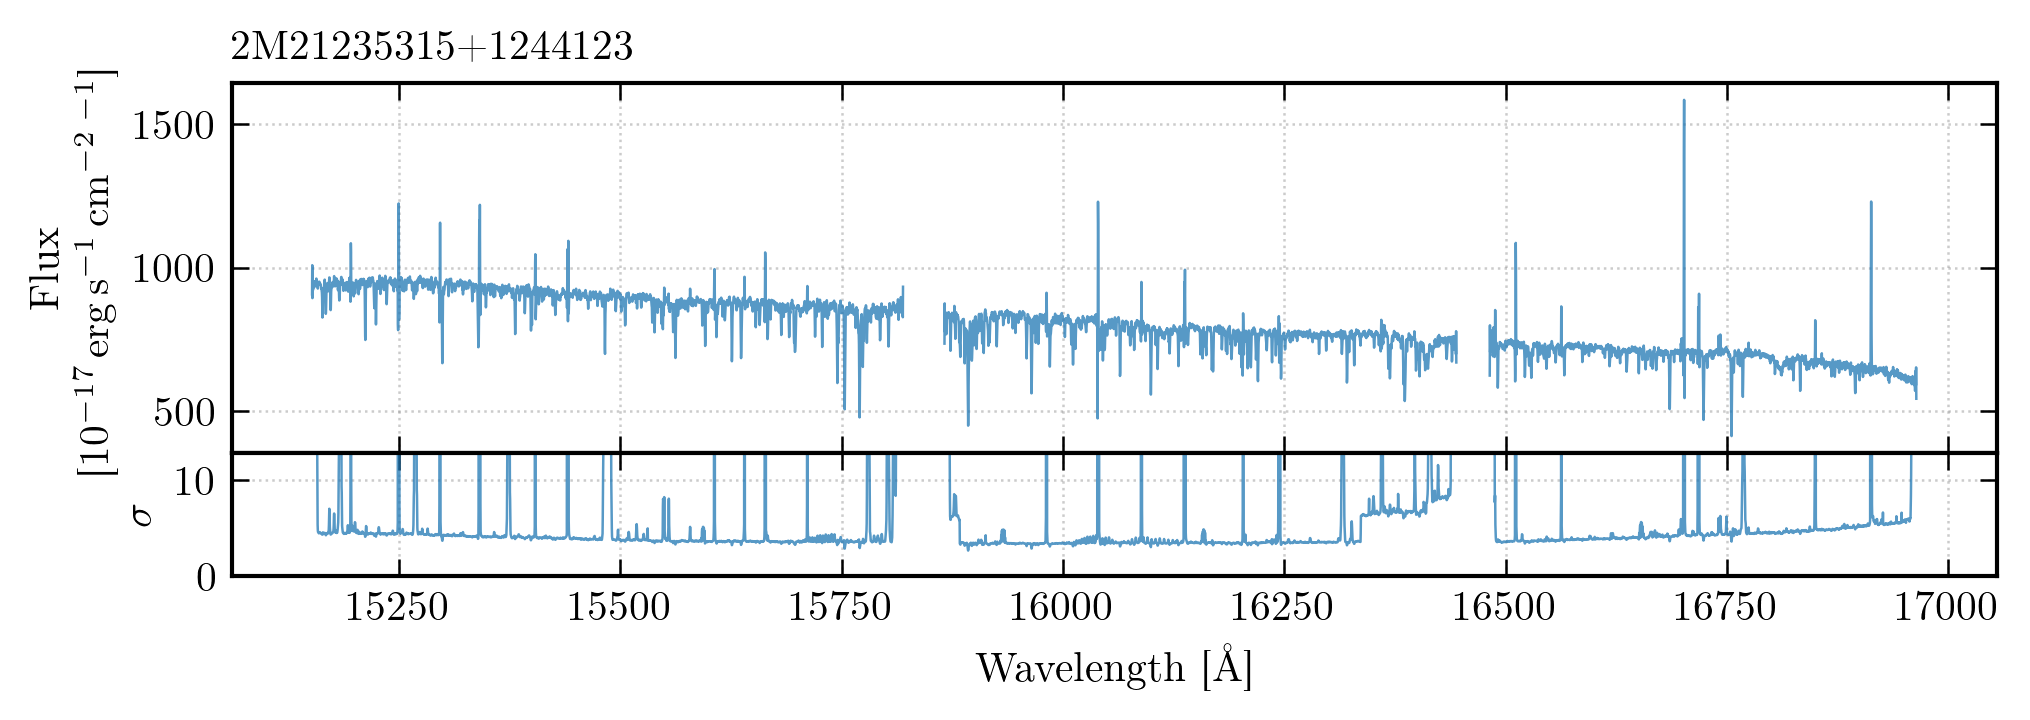

In [7]:
example_id = "2M21235315+1244123"
example_row = training.data[np.array(training.data["apogee_id"], dtype=str) == example_id]
spec_raw = _get_apstar_spectra(
    example_id,
    str(example_row["telescope"][0]),
    str(example_row["field"][0]),
)

axes = plotters.plot_example_spectrum(
    spec_raw["wavelength"], spec_raw["flux"], spec_raw["error"], apogee_id=example_id,
)
plt.show()

## Problem 3 — Pixel Bitmask

The APOGEE pixel bitmask (`APOGEE_PIXMASK`) flags problematic pixels using a bitwise encoding: each bit in a 16-bit integer represents a specific quality flag, and a pixel can have multiple flags set simultaneously. To test whether bit $k$ is set for a pixel, we compute the bitwise AND of the bitmask value with $2^k$: if `(bitmask >> k) & 1 == 1`, that flag is active. The union of multiple bits is tested with `bitmask & mask != 0`, where `mask` is the OR of all flag values of interest.

We mask the following bits by setting $\sigma_\lambda$ to a large sentinel value ($10^6$), the APOGEE convention. This gives them negligible weight ($w \propto 1/\sigma^2 \approx 10^{-12}$) in any subsequent $\chi^2$ fit — effectively zero without requiring special-case handling for infinite values:

| Bit | Name | Description |
|-----|------|-------------|
| 0 | `BADPIX` | Pixel marked bad in the detector dark frame |
| 1 | `CRPIX` | Cosmic ray hit identified in the up-the-ramp sampling |
| 2 | `SATPIX` | Pixel saturated in a significant number of reads |
| 3 | `UNFIXABLE` | Pixel flagged bad and could not be fixed by interpolation |
| 4 | `BADDARK` | Bad pixel in the dark current subtraction |
| 5 | `BADFLAT` | Bad pixel in the flat-field calibration |
| 6 | `BADERR` | Pixel with unreliable error estimate |
| 7 | `NOSKY` | Sky subtraction failed at this pixel |
| 12 | `NODATA` | No data collected (inter-chip gap or unvisited pixel) |

Setting $\sigma_\lambda = 10^6$ for flagged pixels gives them negligible weight ($1/\sigma^2 = 10^{-12}$) in any subsequent chi-squared fit, effectively masking them without discarding the entire spectrum or changing its pixel count. Using a finite sentinel rather than $\infty$ avoids NaN propagation in downstream arithmetic while still making the weight indistinguishable from zero: a pixel with $\sigma = 10^6$ contributes $\sim 10^{12}\times$ less to the Cannon's weighted least squares than a pixel with typical $\sigma \sim 0.01$. This is preferable to deleting pixels outright because it preserves the wavelength registration (all spectra remain 8575-pixel vectors on the same grid) while ensuring that unreliable data does not influence the model. Pixels that already have errors larger than $10^6$ (e.g., from pipeline processing) are left unchanged.

Bits 0–7 are detector- and reduction-level problems; bit 12 is the inter-chip gap. We do not mask the dispersion-related bits (8–11) or the persistence flags (13–14) — they are kept as-is and propagate into the error budget naturally.

The figure below shows the diagnostic for our example star: pixels in red are the union of bits 0–7 and bit 12. Large red blocks at $\sim 15130$, $\sim 15840$, $\sim 16460$, and $\sim 16975$ Å mark the inter-chip gaps (`NODATA`); narrower blocks of red around $\sim 15852$ Å come from `NOSKY` failures over the bright OH airglow; isolated single-pixel hits scattered across the spectrum are cosmic-ray flags (`CRPIX`). This pattern is reproducible across stars and is the source of the "spike" structure we will see in the per-pixel masking-frequency plot below.

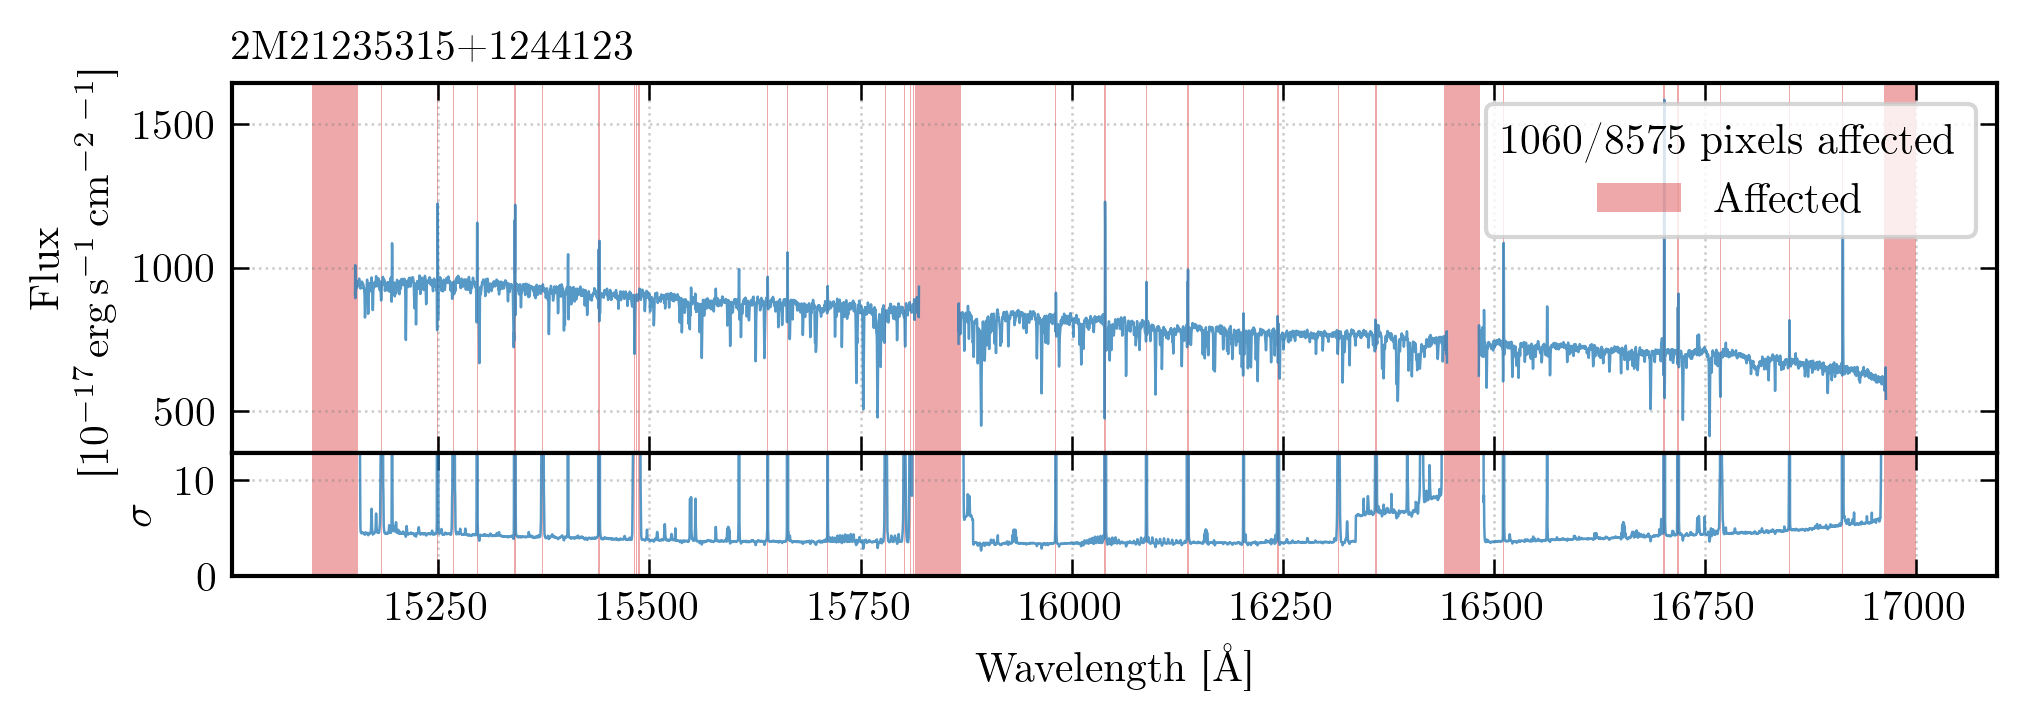

In [8]:
ax = plotters.plot_bitmask_diagnostic(
    spec_raw["wavelength"], spec_raw["flux"], spec_raw["error"], spec_raw["bitmask"],
    apogee_id="2M21235315+1244123",
)
plt.show()

## Problem 4 — Pseudo-Continuum Normalization

### Theory

**True vs pseudo continuum.** The *true* stellar continuum is the smooth flux that would be observed in the absence of all absorption lines — the photospheric blackbody modified by bound-free and free-free opacity. Estimating it requires a physical model of the stellar atmosphere (effective temperature, surface gravity, metallicity), which is precisely what we are trying to measure. This creates a circularity: you need labels to know the continuum, and you need the continuum to measure labels.

**Pseudo-continuum normalization** breaks this circularity by using an *empirical* continuum instead. The idea (Ness et al. 2015, §2.3) is to identify a set of wavelengths whose flux depends only weakly on the stellar labels — pixels where the opacity is dominated by the smooth continuum rather than by specific atomic or molecular transitions. At these "continuum pixels," the flux variation from star to star is driven almost entirely by the broadband SED shape (set by $T_{\rm eff}$, distance, and extinction), not by the label-dependent absorption we want to model.

**Per-chip Chebyshev polynomial fitting.** We fit an independent degree-4 Chebyshev polynomial to each of the three APOGEE detector chips (blue: $\sim$15100–15800 Å; green: $\sim$15860–16430 Å; red: $\sim$16480–16950 Å), using only the pre-identified continuum pixels (529 total across all three chips: 241 blue, 108 green, 180 red) from Ness et al. (2015). The polynomial is fit via inverse-variance weighted least squares ($w_i = 1/\sigma_i^2$), so pixels with larger uncertainties contribute less to the continuum estimate; pixels with $\sigma \geq 10^5$ are excluded entirely from the fit. This threshold is necessary because the Chebyshev fitter treats all input pixels equally in the sense that it has no built-in mechanism to ignore sentinel-valued errors — it simply fits through whatever points it receives. Without this filter, a continuum pixel that was bitmask-flagged (and thus given $\sigma = 10^6$ in Problem 3) would still enter the fit at its original flux value, potentially biasing the polynomial if that flux is corrupted. The $10^5$ threshold sits safely between typical measurement errors ($\sigma \sim 0.01$) and the sentinel ($10^6$), catching all flagged pixels while leaving valid data untouched. The Chebyshev basis is preferred over a monomial basis ($1, x, x^2, \ldots$) because Chebyshev polynomials are orthogonal on $[-1, 1]$ and are far less susceptible to Runge oscillation at the chip edges. Each chip gets its own polynomial — fitting a single polynomial across inter-chip gaps would produce wild oscillations in the gap regions.

After dividing the raw flux by the per-chip polynomial fit, the broadband SED shape (driven by $T_{\rm eff}$, blaze function, and extinction) is removed, and what remains is a unit-mean flux vector whose departures from 1 carry the absorption-line information the Cannon will model. The error array is divided by the same continuum estimate, preserving the per-pixel signal-to-noise ratio.

The 529 continuum pixels (total across all three chips) we use are the published Ness et al. 2015 (§2.3) selection: the original Cannon paper identified them by iteratively finding the pixels whose label sensitivity is below a threshold across a representative training sample. We adopt the published mask rather than re-running the iterative procedure here.

### Normalization diagnostic

The diagnostic plot below has three panels for the example star **2M21235315+1244123** (this is also Checkpoint #1b):

1. **Raw bitmask-corrected flux** with the fitted Chebyshev continuum overlaid as a smooth curve. The continuum should track the overall envelope of the spectrum without dipping into absorption features — verify by eye that the curve passes through the *upper* envelope of the data, not through the line cores.
2. **Continuum polynomial alone** (per chip) showing the three independently-fitted Chebyshev pieces. The discontinuities at the chip gaps are expected and correct: each chip is fit in isolation.
3. **Normalized spectrum** (raw flux / continuum). The continuum is now flat at $\sim 1$, and absorption features are visible as fractional dips below unity. A "good" normalization satisfies two qualitative checks: (a) the residual amplitude in continuum regions is small, of order a few percent or less; (b) there is no broadband tilt left in the normalized spectrum. Failure modes to watch for: a tilted normalized spectrum (Chebyshev too low order or contaminated continuum mask), wiggles at chip edges (polynomial overfitting near boundaries), or normalized fluxes that exceed 1 by more than the noise level (continuum biased low).

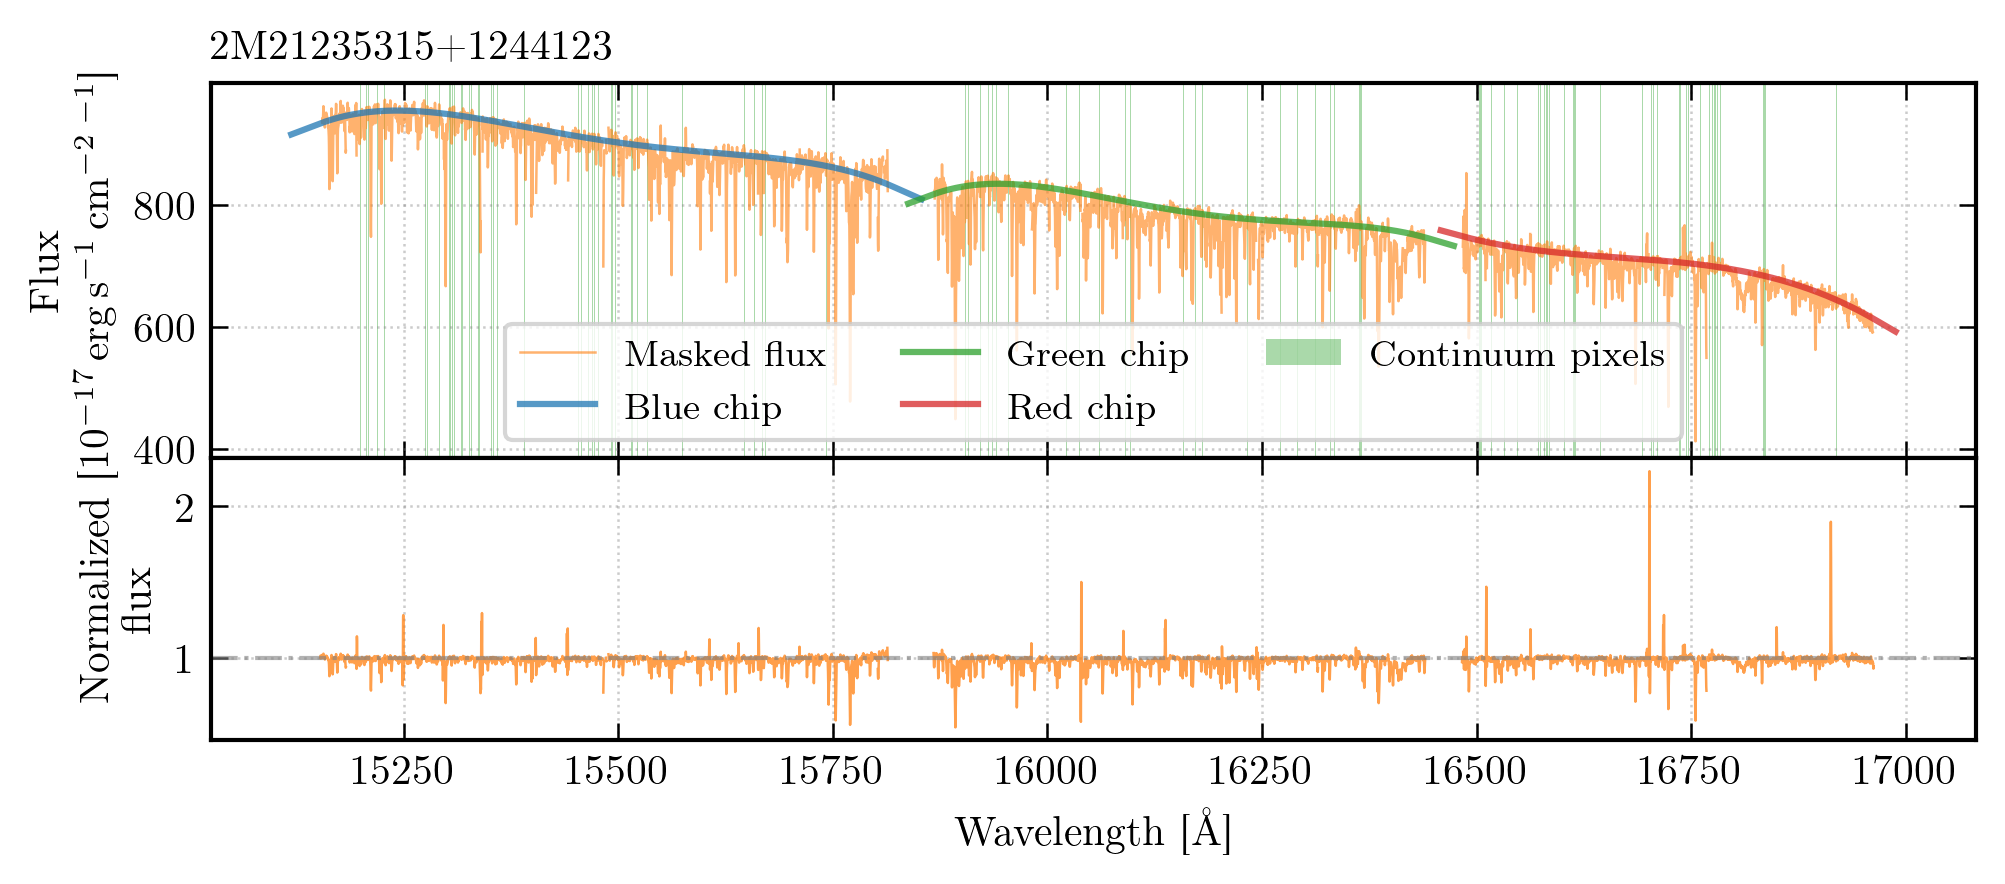

In [9]:
continuum_path = Path("continuum_wavelengths.npz")
continuum_data = np.load(continuum_path)
continuum_mask = continuum_data["continuum"].astype(bool)
wavelength = continuum_data["wavelengths"]

flux_masked, error_masked = _apply_bitmask(
    spec_raw["flux"], spec_raw["error"], spec_raw["bitmask"],
)
flux_norm, error_norm, continuum_fit = _normalize_spectrum(
    flux_masked, error_masked, wavelength, continuum_mask,
    spec_raw["chips"], degree=4,
)

axes = plotters.plot_normalization_diagnostic(
    wavelength, flux_masked, error_masked,
    continuum_fit, flux_norm, error_norm, continuum_mask,
    apogee_id=example_id,
)
plt.show()

### Download and normalize all training spectra

In [10]:
spectra = APOGEESpectra(source=training, continuum_path=continuum_path)
print(f"Flux shape: {spectra.flux.shape}")
print(f"Error shape: {spectra.error.shape}")
print(f"Wavelength shape: {spectra.wavelength.shape}")
print(f"Stars downloaded: {len(spectra)}")

APOGEE spectra:   0%|          | 0/1886 [00:00<?, ?it/s]

Flux shape: (1886, 8575)
Error shape: (1886, 8575)
Wavelength shape: (8575,)
Stars downloaded: 1886


### Bitmask frequency across training set

How often is each pixel masked across all training spectra? Persistent spikes indicate detector regions that are systematically flagged (dead pixels, chip edges) rather than random per-spectrum events. The expected pattern can be predicted in advance from the known instrumental and atmospheric features:

- **Chip gaps** (~15130, ~15840, ~16460, ~16975 Å): all stars are masked at the physical boundaries between APOGEE's three H2RG detectors, where no data is recorded.
- **~15852 Å**: a cluster of bright **OH airglow emission lines** from Earth's upper atmosphere. The sky subtraction pipeline (`NOSKY`, bit 7) fails here because the airglow intensity varies on timescales shorter than the exposure.
- **~16452–16468 Å**: **telluric CO$_2$ absorption** near the green–red chip boundary, compounded by reduced detector sensitivity at the chip edge.
- **~16975 Å**: the **red edge** of APOGEE's wavelength coverage, where detector quantum efficiency drops and strong **telluric H$_2$O absorption** contaminates the signal.

The figure below should show clear all-stars-masked spikes at exactly these wavelengths, and *no* spikes at known stellar absorption features (Brackett series, Fe I, Mg I) — the latter would indicate a serious problem with the bitmask logic.

APOGEE spectra:   0%|          | 0/1886 [00:00<?, ?it/s]

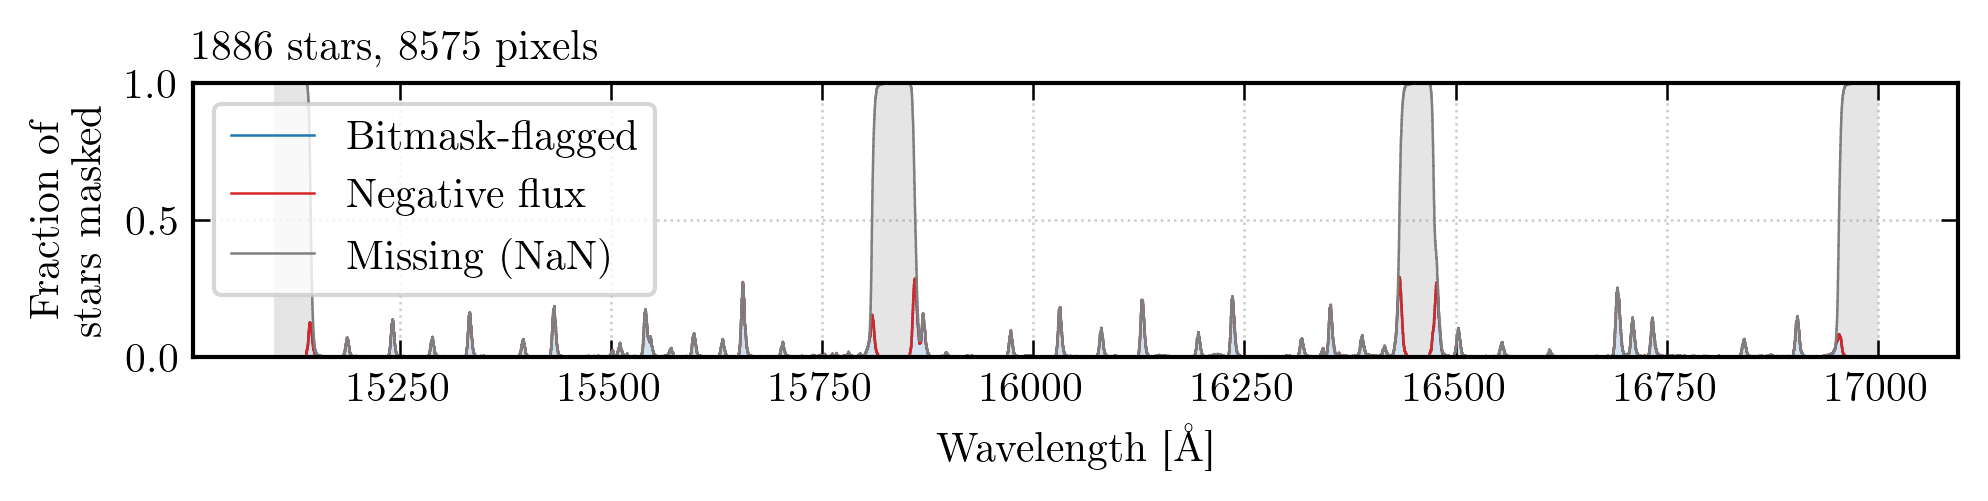

In [11]:
raw_spectra = _fetch_apstar_batch(training.data)
flux_raw_all = np.array([s["flux"] for s in raw_spectra])
bitmask_raw_all = np.array([s["bitmask"] for s in raw_spectra])

ax = plotters.plot_bitmask_frequency(spectra.wavelength, flux_raw_all, bitmask_raw_all)
plt.show()


### Per-pixel SNR and Cannon trainability

The Cannon skips pixels that fail either of two trainability criteria:

1. **Data completeness**: $\geq 99.7\%$ of training stars must have finite errors at that pixel. This excludes the chip-gap transition zones where many stars have NaN.

2. **Median per-pixel SNR $\geq 3$**: After continuum normalization, the last few pixels before each chip gap can have *finite* but enormous errors — the continuum polynomial extrapolates toward small values at the chip edge, and dividing by a small continuum inflates the normalized error. These pixels pass the completeness check (almost every star has a finite error) but the measurement carries negligible information.

The cell below quantifies the problem. At the two worst pixels ($\lambda \approx 16430$ Å, the last trained pixels before the green/red chip gap), nearly all training stars have finite errors (`valid_frac` $\approx 1$), but the median normalized SNR is $< 2$. Without the SNR criterion, the Cannon would train on these pixels and the scatter floor (`median($\sigma^2$)`) would be $\sim 0.95$ — almost 1000$\times$ the typical mid-chip value of $\sim 0.0002$. With the SNR $\geq 3$ cut, these 2 pixels are excluded along with the 109 pixels already caught by the completeness threshold.


In [12]:
# Per-pixel median SNR across training set (using normalized flux/error)
n_stars, n_pix = spectra.flux.shape
finite_mask = (
    np.isfinite(spectra.flux)
    & np.isfinite(spectra.error)
    & (spectra.error > 0)
)
with np.errstate(invalid="ignore"):
    snr = np.where(finite_mask, np.abs(spectra.flux) / spectra.error, np.nan)
median_snr = np.nanmedian(snr, axis=0)
valid_frac = np.mean(np.isfinite(spectra.error), axis=0)

# Pixels that pass completeness but fail SNR
complete = valid_frac >= 0.997
low_snr = (median_snr < 3) & complete
print(f"Pixels passing completeness (valid_frac >= 0.997): {complete.sum()}")
print(f"Of those, median SNR < 3: {low_snr.sum()}")
print()
if low_snr.sum() > 0:
    for p in np.where(low_snr)[0]:
        print(
            f"  λ={spectra.wavelength[p]:.2f} Å: "
            f"valid_frac={valid_frac[p]:.4f}, "
            f"median SNR={median_snr[p]:.2f}, "
            f"median σ²={np.nanmedian(spectra.error[:, p]**2):.4f}"
        )
    print()
    print("For comparison, a typical mid-chip pixel (λ≈16200 Å):")
    p_mid = np.argmin(np.abs(spectra.wavelength - 16200))
    print(
        f"  λ={spectra.wavelength[p_mid]:.2f} Å: "
        f"median SNR={median_snr[p_mid]:.1f}, "
        f"median σ²={np.nanmedian(spectra.error[:, p_mid]**2):.6f}"
    )


/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Pixels passing completeness (valid_frac >= 0.997): 7530
Of those, median SNR < 3: 1

  λ=16429.94 Å: valid_frac=0.9973, median SNR=2.74, median σ²=0.1242

For comparison, a typical mid-chip pixel (λ≈16200 Å):
  λ=16200.04 Å: median SNR=168.8, median σ²=0.000029


In [13]:
n_stars, n_pixels = flux_raw_all.shape

nan_mask = np.isnan(flux_raw_all)
bm_mask = np.zeros_like(flux_raw_all, dtype=bool)
for bit in APOGEE_BAD_PIXMASK_BITS:
    bm_mask |= (bitmask_raw_all & (1 << bit)).astype(bool)
bm_mask &= ~nan_mask
neg_mask = (flux_raw_all < 0) & ~nan_mask & ~bm_mask
good_mask = ~nan_mask & ~bm_mask & ~neg_mask

good_per_px = np.sum(good_mask, axis=0)
bm_per_px = np.sum(bm_mask, axis=0)
neg_per_px = np.sum(neg_mask, axis=0)
nan_per_px = np.sum(nan_mask, axis=0)

good_frac = good_per_px / n_stars

summary = pd.DataFrame({
    "Category": [
        "100% good",
        "≥ 99.7% good",
        "≥ 95% good",
        "≥ 68% good",
        "Any bitmask-flagged",
        "Any negative flux",
        "Any missing (NaN)",
    ],
    "Pixels": [
        np.sum(good_frac == 1.0),
        np.sum(good_frac >= 0.997),
        np.sum(good_frac >= 0.95),
        np.sum(good_frac >= 0.68),
        np.sum(bm_per_px > 0),
        np.sum(neg_per_px > 0),
        np.sum(nan_per_px > 0),
    ],
})
summary["% of pixels"] = (summary["Pixels"] / n_pixels * 100).map("{:.1f}%".format)

print(f"Pixel breakdown ({n_pixels} total, {n_stars} stars):")
summary

Pixel breakdown (8575 total, 1886 stars):


,Category,Pixels,% of pixels
0,100% good,294,3.4%
1,≥ 99.7% good,4398,51.3%
2,≥ 95% good,6998,81.6%
3,≥ 68% good,7712,89.9%
4,Any bitmask-flagged,7808,91.1%
5,Any negative flux,40,0.5%
6,Any missing (NaN),1194,13.9%


The summary table breaks down how much of the spectrum is usable. About **3.4% of pixels are good in 100% of training stars** (these are the pristine wavelengths far from any chip edge or telluric region), about **51% are good in $\geq 99.7\%$** of stars (the bulk of the useful spectrum), and **91% are flagged at least once** somewhere in the training set (driven by the chip edges and OH airglow). The mean per-star masked fraction is $\sim 9\%$, dominated by chip-edge geometry rather than per-star anomalies.

Crucially, masked pixels are *down-weighted, not removed*: setting $\sigma_\lambda = 10^6$ gives them negligible contribution to any subsequent $\chi^2$ but keeps the spectrum vector at full length. This means the Cannon training pipeline can use slightly different sets of "good" pixels for different stars without any per-spectrum bookkeeping. The corresponding cost is per-pixel: at the masked-frequency spikes the effective number of training stars contributing to a given pixel can drop sharply, so the per-pixel polynomial coefficients there are correspondingly less well-determined. NB 02 will address this with a per-pixel validity threshold and a scatter floor.

### Robustness check — similar stars comparison

Stars with similar labels should produce nearly identical normalized spectra, because (by hypothesis) the labels fully determine the photospheric spectrum. Significant disagreements would indicate either (a) a problem with our continuum normalization (introduces label-independent variance), (b) ASPCAP labels that are inconsistent across stars at fixed atmospheric parameters, or (c) genuine astrophysical scatter at fixed labels (binarity, rotation, peculiar abundances) that the Cannon will later have to absorb into its intrinsic-scatter term $s_\lambda^2$.

We pick the example star **2M21235315+1244123** as the reference and find the five stars closest to it in label space (Euclidean distance in standardized labels). The top panel below overlays all six normalized spectra (pixels with sentinel errors are excluded). The bottom panel shows the per-pixel standard deviation $\sigma_{\rm pix}$ across the six spectra, quantifying the star-to-star scatter at each wavelength.

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


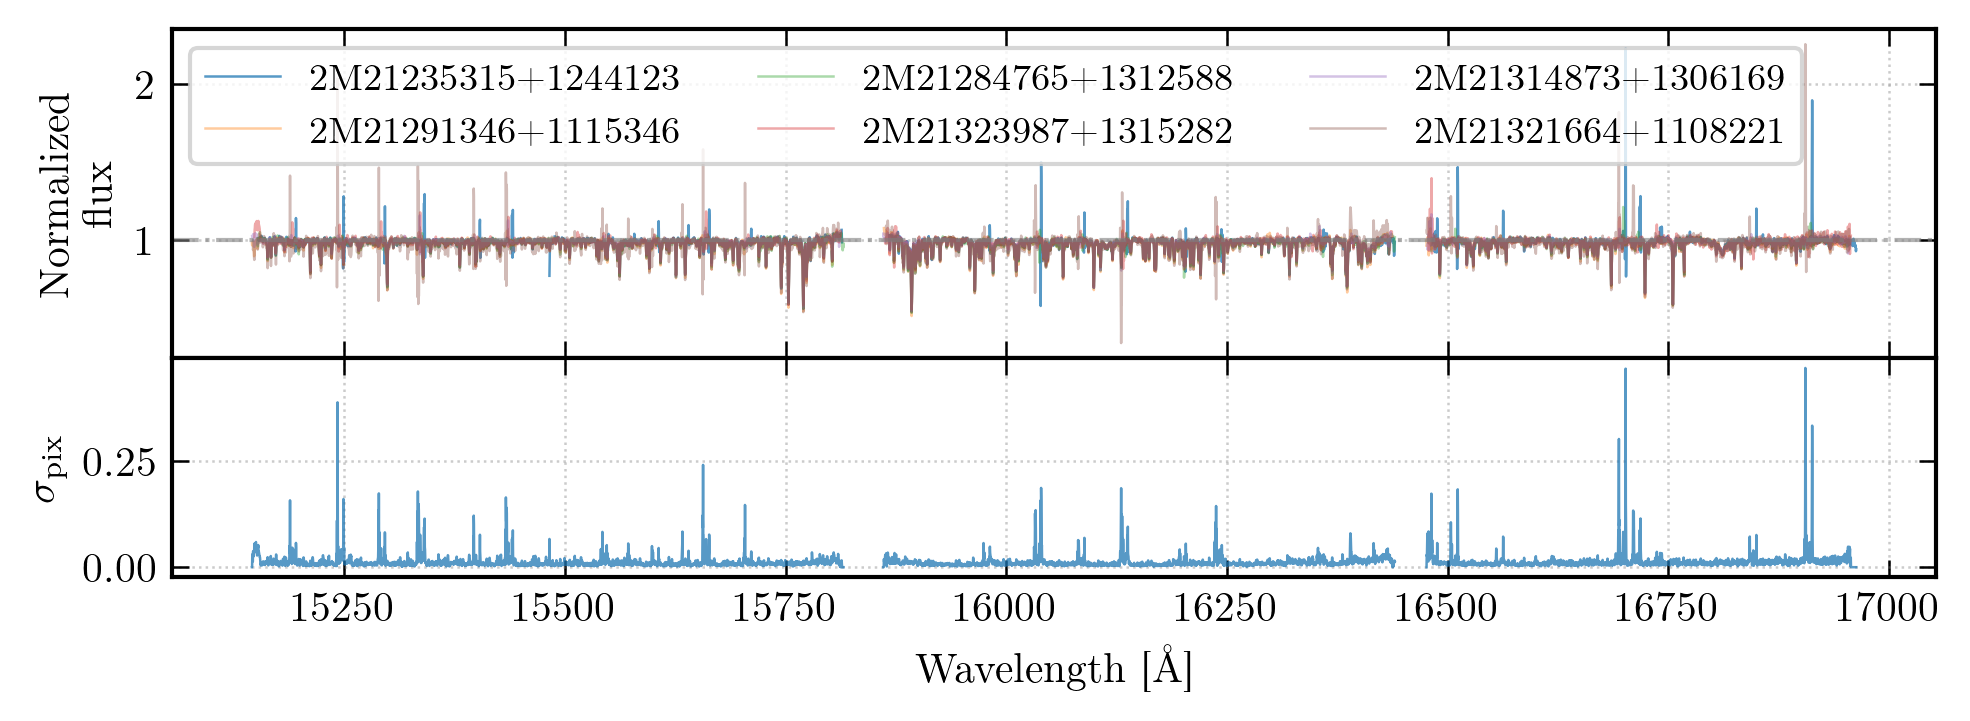

In [14]:
# The spectra are downloaded in catalog order, so apogee_ids matches training.data order.
# Build label array directly from catalog order.
label_cols = ["teff", "logg", "fe_h", "mg_fe", "si_fe"]
spec_labels = np.column_stack([training.data[col] for col in label_cols])

# Use the example star as reference
ref_idx = int(np.where(spectra.apogee_ids == example_id)[0][0])

ax = plotters.plot_similar_stars_comparison(
    spectra.wavelength, spectra.flux, spectra.error,
    spec_labels, spectra.apogee_ids, ref_idx, n_similar=5,
)
plt.show()

The spectra of the six similar-label stars are visually nearly indistinguishable in the top panel — line depths, line profiles, and the continuum level all agree to within a few percent, confirming that our pseudo-continuum normalization produces consistent results for stars with similar atmospheric parameters.

The scatter panel ($\sigma_{\rm pix}$) makes this quantitative. The median per-pixel scatter is very small ($\sim 0.01$, i.e. $\sim 1\%$ of the normalized continuum), and the scatter is **flat across absorption features**. This is the critical diagnostic: if the normalization were introducing label-dependent artifacts, we would see $\sigma_{\rm pix}$ spike at absorption line cores (where the continuum fit is most sensitive to the choice of continuum pixels). Instead, the scatter is driven by:

1. **Isolated spurious peaks** at individual wavelengths — these are unflagged cosmic rays or detector glitches in one of the six stars, not astrophysical variability. They appear as narrow single-pixel spikes in $\sigma_{\rm pix}$ and will be absorbed by the Cannon's per-pixel intrinsic scatter term $s_\lambda^2$.
2. **Chip-edge regions** ($\sim$15800, $\sim$16430 Å) where the Chebyshev polynomial is extrapolating slightly beyond the outermost continuum pixel, producing $\sim 2$–$3\%$ normalization scatter.
3. **Photon noise** — a floor set by the finite SNR of each spectrum.

Crucially, the scatter does **not** correlate with absorption-line depth: strong features like the Brackett series and CO bandheads show the same low scatter as the inter-line continuum. This confirms that the normalization preserves relative line depths faithfully and that downstream Cannon training will model real label-driven spectral variation, not normalization artifacts.

### Save training spectra

We persist the post-cut, normalized training set to `training_spectra.npz` for use by all downstream notebooks. The file contains the wavelength grid, the $(1886, 8575)$ flux and error arrays, the labels and label names, the APOGEE IDs, the continuum mask, and two ASPCAP per-star quality flags:

- **`starflag`** is a bitmask of *target-level* warnings: low SNR visits, persistent radial-velocity scatter, suspect spectroscopy, etc. A non-zero `starflag` does not necessarily invalidate the labels but suggests caution.
- **`aspcapflag`** is a bitmask of *ASPCAP pipeline* warnings: parameter rails (e.g., a label hit a grid edge during the fit), sigma-truncation, or rejected calibration. Bits in `aspcapflag` are the most direct signal that a particular set of ASPCAP labels may be unreliable.

We will use both flags in NB 03 (cross-validation) when investigating outliers — stars where the Cannon's fitted labels disagree with ASPCAP often have non-zero flags, indicating that ASPCAP itself was uncertain.

In [15]:
# Labels are in catalog order (same as spectra download order)
labels_all = np.column_stack([training.data[col] for col in label_cols])
starflag = np.array(training.data["starflag"])
aspcapflag = np.array(training.data["aspcapflag"])
fields = np.array(training.data["field"], dtype=str)

np.savez_compressed(
    "training_spectra.npz",
    wavelength=spectra.wavelength,
    flux=spectra.flux,
    error=spectra.error,
    labels=labels_all,
    label_names=np.array(LABEL_NAMES),
    apogee_ids=spectra.apogee_ids,
    continuum_mask=spectra.continuum_mask,
    starflag=starflag,
    aspcapflag=aspcapflag,
    fields=fields,
)
print("Saved training_spectra.npz")
print(f"  flux: {spectra.flux.shape}")
print(f"  labels: {labels_all.shape}")
print(f"  stars: {len(spectra)}")

Saved training_spectra.npz
  flux: (1886, 8575)
  labels: (1886, 5)
  stars: 1886
